In [43]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

In [44]:
df = pd.read_csv('heart.csv')
print(df.head())

   Age  RestingBP  Cholesterol  MaxHR  Oldpeak Sex ChestPainType  FastingBS  \
0   40        140          289    172      0.0   M           ATA          0   
1   49        160          180    156      1.0   F           NAP          0   
2   37        130          283     98      0.0   M           ATA          0   
3   48        138          214    108      1.5   F           ASY          0   
4   54        150          195    122      0.0   M           NAP          0   

  RestingECG ExerciseAngina ST_Slope  HeartDisease  
0     Normal              N       Up             0  
1     Normal              N     Flat             1  
2         ST              N       Up             0  
3     Normal              Y     Flat             1  
4     Normal              N       Up             0  


In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   RestingBP       918 non-null    int64  
 2   Cholesterol     918 non-null    int64  
 3   MaxHR           918 non-null    int64  
 4   Oldpeak         918 non-null    float64
 5   Sex             918 non-null    object 
 6   ChestPainType   918 non-null    object 
 7   FastingBS       918 non-null    int64  
 8   RestingECG      918 non-null    object 
 9   ExerciseAngina  918 non-null    object 
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [46]:
df.describe()

,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,FastingBS,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,136.809368,0.887364,0.233115,0.553377
std,9.432617,18.514154,109.384145,25.460334,1.066570,0.423046,0.497414
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,138.000000,0.600000,0.000000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000,1.000000


In [47]:
print(df['HeartDisease'].value_counts())

HeartDisease
1    508
0    410
Name: count, dtype: int64


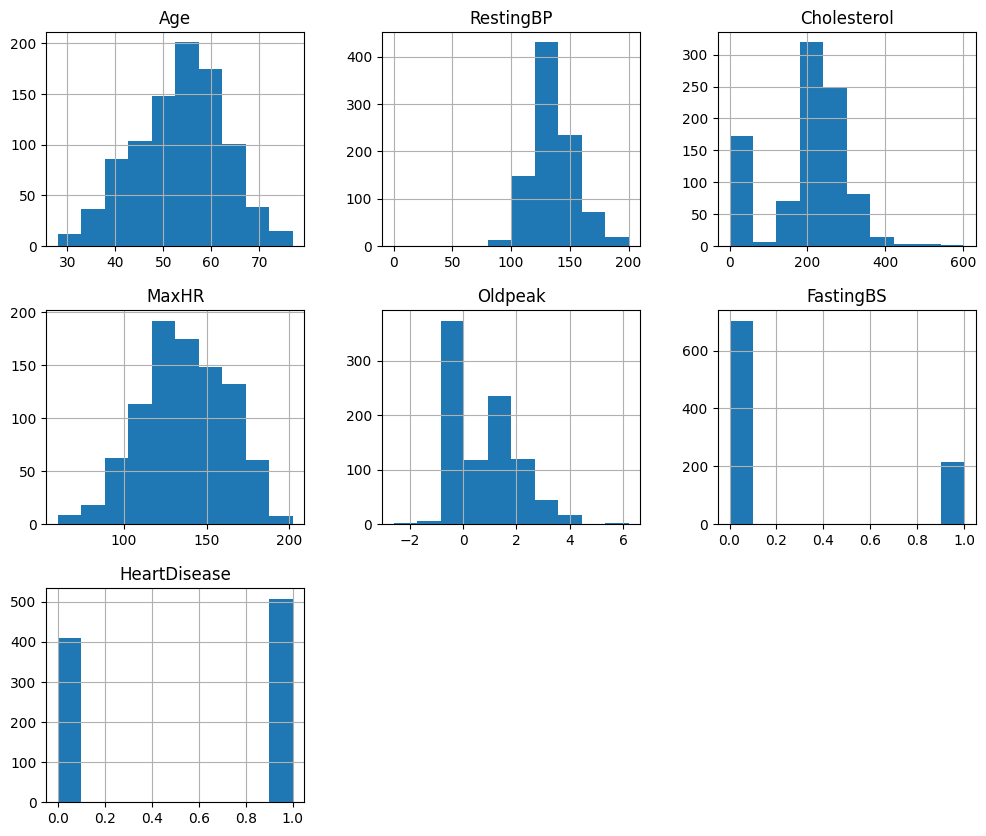

In [48]:
df.hist(figsize=(12,10))
plt.show()

In [49]:
df = pd.get_dummies(df)
df = df.astype(float)
print(df.head())

    Age  RestingBP  Cholesterol  MaxHR  Oldpeak  FastingBS  HeartDisease  \
0  40.0      140.0        289.0  172.0      0.0        0.0           0.0   
1  49.0      160.0        180.0  156.0      1.0        0.0           1.0   
2  37.0      130.0        283.0   98.0      0.0        0.0           0.0   
3  48.0      138.0        214.0  108.0      1.5        0.0           1.0   
4  54.0      150.0        195.0  122.0      0.0        0.0           0.0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0    0.0    1.0                0.0  ...                0.0               0.0   
1    1.0    0.0                0.0  ...                1.0               0.0   
2    0.0    1.0                0.0  ...                0.0               0.0   
3    1.0    0.0                1.0  ...                0.0               0.0   
4    0.0    1.0                0.0  ...                1.0               0.0   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseA

In [50]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(X.head())
print(y.head())

    Age  RestingBP  Cholesterol  MaxHR  Oldpeak  FastingBS  Sex_F  Sex_M  \
0  40.0      140.0        289.0  172.0      0.0        0.0    0.0    1.0   
1  49.0      160.0        180.0  156.0      1.0        0.0    1.0    0.0   
2  37.0      130.0        283.0   98.0      0.0        0.0    0.0    1.0   
3  48.0      138.0        214.0  108.0      1.5        0.0    1.0    0.0   
4  54.0      150.0        195.0  122.0      0.0        0.0    0.0    1.0   

   ChestPainType_ASY  ChestPainType_ATA  ChestPainType_NAP  ChestPainType_TA  \
0                0.0                1.0                0.0               0.0   
1                0.0                0.0                1.0               0.0   
2                0.0                1.0                0.0               0.0   
3                1.0                0.0                0.0               0.0   
4                0.0                0.0                1.0               0.0   

   RestingECG_LVH  RestingECG_Normal  RestingECG_ST  ExerciseA

In [51]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [53]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)


In [55]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [56]:
model = MLP(X_train.shape[1])

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [57]:
epochs = 500

train_losses = []
val_losses = []

train_acc = []
val_acc = []

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    preds = (outputs > 0.5).float()
    acc = (preds == y_train).float().mean()
    train_acc.append(acc.item())

    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

        val_losses.append(val_loss.item())

        val_preds = (val_outputs > 0.5).float()
        val_acc_epoch = (val_preds == y_val).float().mean()
        val_acc.append(val_acc_epoch.item())

    print(f"Epoch {epoch+1}: loss={loss.item():.4f}, val_loss={val_loss.item():.4f}")


Epoch 1: loss=0.6928, val_loss=0.6906
Epoch 2: loss=0.6892, val_loss=0.6875
Epoch 3: loss=0.6855, val_loss=0.6845
Epoch 4: loss=0.6819, val_loss=0.6814
Epoch 5: loss=0.6782, val_loss=0.6782
Epoch 6: loss=0.6746, val_loss=0.6751
Epoch 7: loss=0.6710, val_loss=0.6719
Epoch 8: loss=0.6674, val_loss=0.6687
Epoch 9: loss=0.6637, val_loss=0.6656
Epoch 10: loss=0.6600, val_loss=0.6624
Epoch 11: loss=0.6563, val_loss=0.6592
Epoch 12: loss=0.6526, val_loss=0.6560
Epoch 13: loss=0.6489, val_loss=0.6528
Epoch 14: loss=0.6451, val_loss=0.6495
Epoch 15: loss=0.6413, val_loss=0.6463
Epoch 16: loss=0.6375, val_loss=0.6430
Epoch 17: loss=0.6335, val_loss=0.6396
Epoch 18: loss=0.6295, val_loss=0.6362
Epoch 19: loss=0.6254, val_loss=0.6327
Epoch 20: loss=0.6212, val_loss=0.6291
Epoch 21: loss=0.6170, val_loss=0.6255
Epoch 22: loss=0.6126, val_loss=0.6217
Epoch 23: loss=0.6082, val_loss=0.6179
Epoch 24: loss=0.6037, val_loss=0.6140
Epoch 25: loss=0.5991, val_loss=0.6100
Epoch 26: loss=0.5944, val_loss=0.

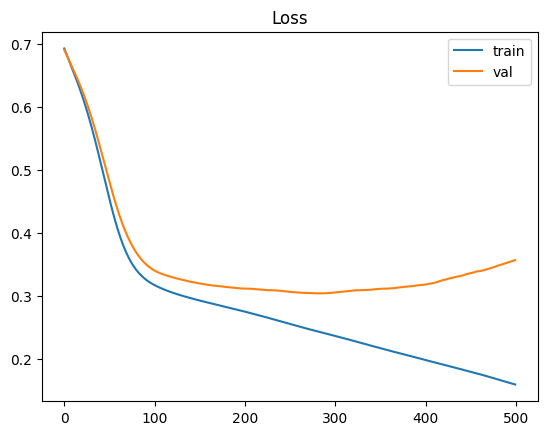

In [63]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.legend()
plt.title("Loss")
plt.show()


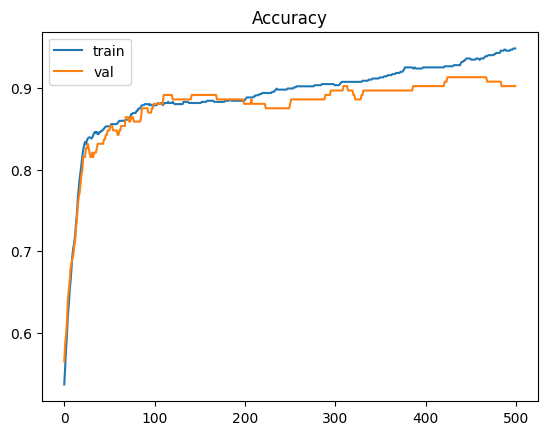

In [64]:
plt.plot(train_acc, label="train")
plt.plot(val_acc, label="val")
plt.legend()
plt.title("Accuracy")
plt.show()